# Data Preparation

In [34]:
import os
project_path = '/content/drive/MyDrive/Pomona/2026/Rosetta_Commons/DrewLab/PDL1_4'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

In [35]:
import pandas as pd
final_design_stats = pd.read_csv('final_design_stats.csv')
initial_ids = final_design_stats.iloc[:, 1]
processed_ids = initial_ids.astype(str).apply(lambda x: x.split('_mpnn')[0] if '_mpnn' in x else x)
good = processed_ids.drop_duplicates().tolist()

In [36]:
trajectory_filepath = os.path.join(project_path, 'trajectory_stats.csv')
trajectory_df = pd.read_csv(trajectory_filepath)
trajectory_ids = set(trajectory_df['Design'].astype(str).drop_duplicates().tolist())
good_set = set(good)
bad = list(trajectory_ids.difference(good_set))

In [37]:
len(good)

30

In [38]:
len(bad)

41

In [39]:
import re

def extract_stage_times(filepath):
    """
    Reads a file, extracts the times for Stage 1, Stage 2, Stage 3, and Stage 4,
    and returns them as a list of floats, with NaN for missing stages.

    Args:
        filepath (str): The path to the stage_times.txt file.

    Returns:
        list: A list of four floats representing the stage times (or NaN if missing).
    """
    stage_times = [float('nan')] * 4 # Initialize with NaN for 4 stages
    with open(filepath, 'r') as f:
        for line in f:
            # Use a regex to find lines starting with 'Stage X:' and extract the stage number and time
            match = re.search(r'Stage ([1-4]):\s+\S+\s+(\d+\.\d+)s', line)
            if match:
                stage_number = int(match.group(1))
                time_value = float(match.group(2))
                # Assign time to the correct index (stage_number - 1)
                if 1 <= stage_number <= 4:
                    stage_times[stage_number - 1] = time_value
    return stage_times

print("Function 'extract_stage_times' redefined to handle missing stages with NaN.")

Function 'extract_stage_times' redefined to handle missing stages with NaN.


In [40]:
import numpy as np

all_data = {}
missing_seqmatrix_files = []

for identifier in good:
    status = True
    stage_times = extract_stage_times(f'{identifier}_stage_times.txt')
    seqmatrix = None
    seqmatrix_filepath = os.path.join(project_path, f'{identifier}_seqmatrix.npy')
    seqmatrix = np.load(seqmatrix_filepath)
    seqmatrix = np.delete(seqmatrix, 4, axis=2)
    all_data[identifier] = (status, seqmatrix, stage_times)

for identifier in bad:
    status = False
    stage_times = extract_stage_times(f'{identifier}_stage_times.txt')
    seqmatrix = None
    seqmatrix_filepath = os.path.join(project_path, f'{identifier}_seqmatrix.npy')
    seqmatrix = np.load(seqmatrix_filepath)
    seqmatrix = np.delete(seqmatrix, 4, axis=2)
    all_data[identifier] = (status, seqmatrix, stage_times)

dataframe_data = []

for identifier, data_tuple in all_data.items():
    status, seqmatrix_data, stage_times_list = data_tuple
    dataframe_data.append({
        'Design': identifier,
        'Good': status,
        'Seqmatrix': seqmatrix_data,
        'Stage Time': stage_times_list
    })

df = pd.DataFrame(dataframe_data)

In [41]:
df = pd.merge(df, trajectory_df[['Design', 'Length']], on='Design')

In [42]:
import numpy as np
import glob

def process_extra_npy_files(df, good_list, bad_list):
    all_npy_files = [f for f in os.listdir('.') if f.endswith('_seqmatrix.npy')]

    existing_designs = set(good_list) | set(bad_list)
    extra_designs = []
    for f in all_npy_files:
        design_id = f.replace('_seqmatrix.npy', '')
        if design_id not in existing_designs:
            extra_designs.append(design_id)

    new_rows = []
    for design in extra_designs:
        match = re.search(r'_l(\d+)_', design)
        length = int(match.group(1)) if match else np.nan

        stage_times_path = f'{design}_stage_times.txt'
        stage_times = extract_stage_times(stage_times_path)

        seqmatrix = np.load(f'{design}_seqmatrix.npy')
        seqmatrix = np.delete(seqmatrix, 4, axis=2)

        new_rows.append({
            'Design': design,
            'Good': np.nan,
            'Seqmatrix': seqmatrix,
            'Stage Time': stage_times,
            'Length': length
        })

    if new_rows:
        new_df = pd.DataFrame(new_rows)
        # Append to existing df
        df = pd.concat([df, new_df], ignore_index=True)

    return df

df = process_extra_npy_files(df, good, bad)
df.tail()

,Design,Good,Seqmatrix,Stage Time,Length
93,PDL1_l82_s32545,NaN,"[[[0.011904836, -0.0025381865, 0.002677435, 0....","[174.0, 68.8, 9.1, nan]",82
94,PDL1_l88_s889063,NaN,"[[[0.03264581, -0.006216827, -0.012078596, 0.0...","[161.2, 63.4, 9.5, 14.5]",88
95,PDL1_l93_s660248,NaN,"[[[0.04085894, 0.012815414, -0.021789523, -0.0...","[177.9, 52.6, nan, nan]",93
96,PDL1_l98_s454283,NaN,"[[[-0.00974007, 0.0202322, 0.0030574924, -0.01...","[191.2, nan, nan, nan]",98
97,PDL1_l99_s966961,NaN,"[[[0.01262152, -0.009633597, 0.0047083693, 0.0...","[188.0, nan, nan, nan]",99


In [43]:
df.head(1)

,Design,Good,Seqmatrix,Stage Time,Length
0,PDL1_l135_s770897,1.0,"[[[0.0076275766, 0.031456538, -0.018696928, 2....","[228.1, 113.6, 8.3, 39.5]",135


In [44]:
df.shape

(98, 5)

In [45]:
df[df['Design'] == 'PDL1_l98_s454283']

,Design,Good,Seqmatrix,Stage Time,Length
96,PDL1_l98_s454283,NaN,"[[[-0.00974007, 0.0202322, 0.0030574924, -0.01...","[191.2, nan, nan, nan]",98


In [46]:
df.iloc[94]['Seqmatrix'].shape

(141, 88, 19)

# Time

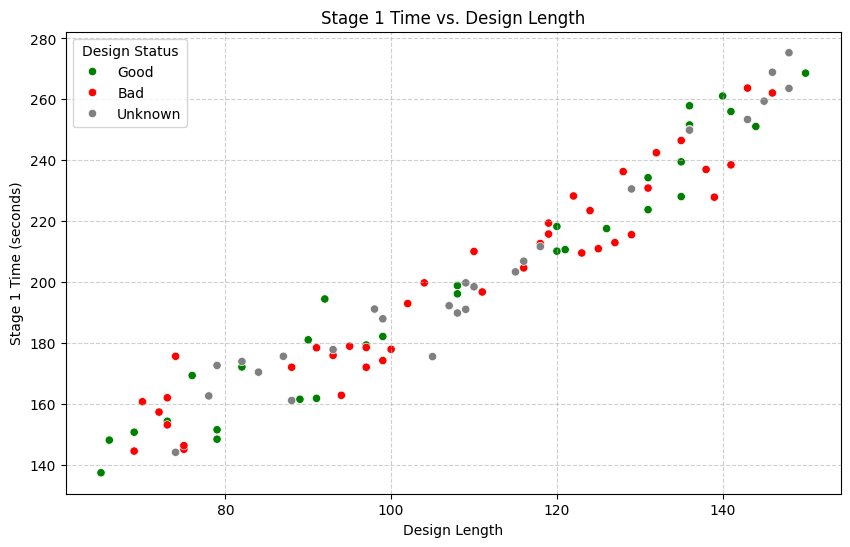

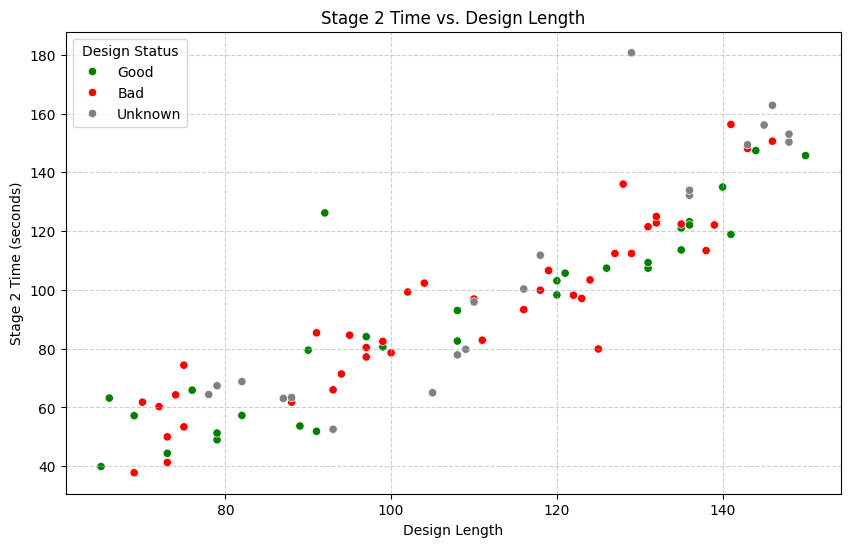

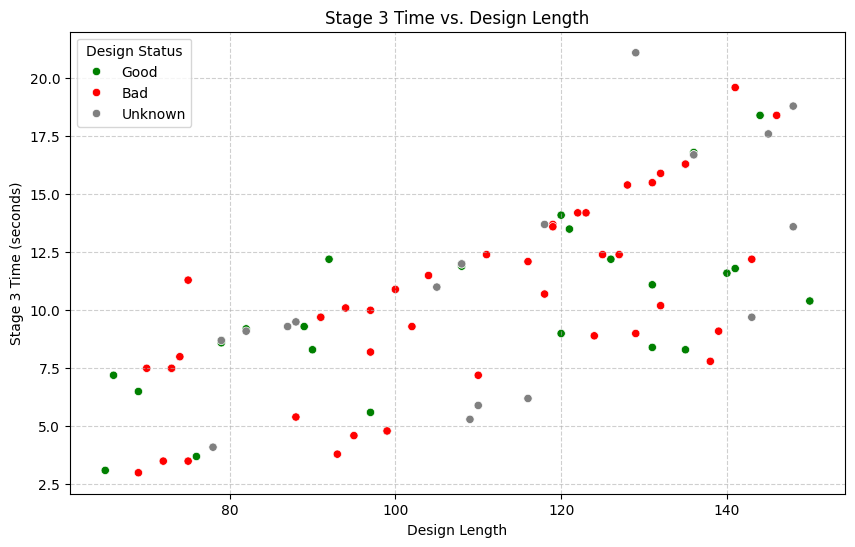

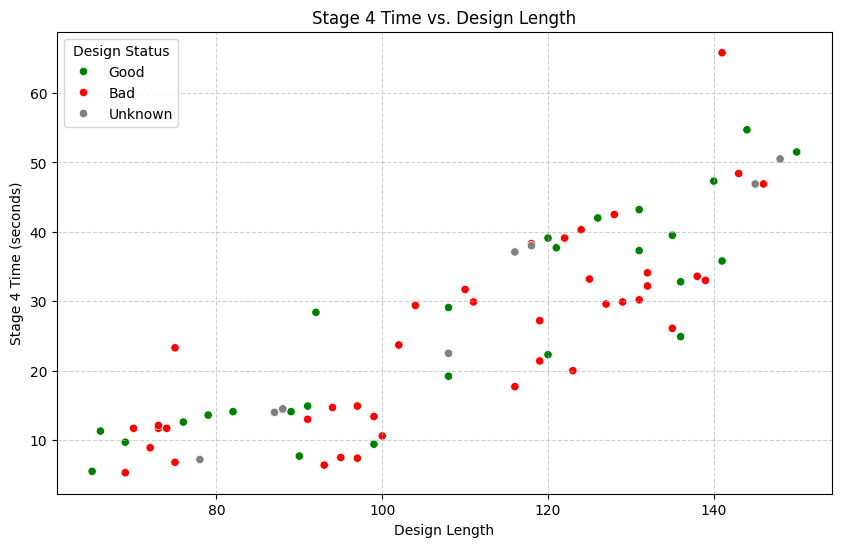

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Map values to strings to ensure the legend and palette match perfectly
plot_df = df.copy()
plot_df['Status'] = plot_df['Good'].map({1.0: 'Good', 0.0: 'Bad', True: 'Good', False: 'Bad'}).fillna('Unknown')

for stage_idx in [0, 1, 2, 3]:
    stage_num = stage_idx + 1
    current_stage_time = plot_df['Stage Time'].apply(lambda x: x[stage_idx])

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=plot_df,
        x='Length',
        y=current_stage_time,
        hue='Status',
        palette={'Good': 'green', 'Bad': 'red', 'Unknown': 'gray'}
    )

    plt.title(f'Stage {stage_num} Time vs. Design Length')
    plt.xlabel('Design Length')
    plt.ylabel(f'Stage {stage_num} Time (seconds)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Design Status')
    plt.show()

# PCA Analysis

### Iteractive Individual Design Trajectories

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from ipywidgets import interact, IntSlider

# Get sequence matrix from the first design
traj_data = df.iloc[33]['Seqmatrix']
traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data

design_name = df.iloc[33]['Design']
num_iterations = traj_data.shape[0]

# ------------------------------------------------------------------
# Each iteration (L, 19) -> flatten to one vector (1, L*19)
# ------------------------------------------------------------------
X = traj_data.reshape(num_iterations, -1)

# PCA across all iterations
pca = PCA(n_components=2)
traj_2d = pca.fit_transform(X)

print(f"Original shape: {traj_data.shape}")
print(f"Flattened shape: {X.shape}")
print(f"PCA shape: {traj_2d.shape}")

# ------------------------------------------------------------------
# Interactive trajectory plot
# ------------------------------------------------------------------
def plot_trajectory(step):
    plt.figure(figsize=(10, 8))

    # Full trajectory
    plt.plot(
        traj_2d[:, 0],
        traj_2d[:, 1],
        color='lightgray',
        linestyle='--',
        alpha=0.5
    )

    # Path up to current step
    plt.plot(
        traj_2d[:step + 1, 0],
        traj_2d[:step + 1, 1],
        '-o',
        color='blue',
        markersize=4,
        alpha=0.8,
        label=f'Trajectory up to iter {step}'
    )

    # Start point
    plt.scatter(
        traj_2d[0, 0],
        traj_2d[0, 1],
        c='red',
        marker='x',
        s=150,
        linewidths=3,
        label='Start'
    )

    # Current point
    plt.scatter(
        traj_2d[step, 0],
        traj_2d[step, 1],
        c='green',
        marker='*',
        s=250,
        label=f'Iteration {step}'
    )

    plt.xlabel(
        f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)'
    )
    plt.ylabel(
        f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)'
    )
    plt.title(f'PCA Optimization Trajectory: {design_name}')
    plt.legend()
    plt.grid(True)

    plt.xlim(
        traj_2d[:, 0].min() - 1,
        traj_2d[:, 0].max() + 1
    )
    plt.ylim(
        traj_2d[:, 1].min() - 1,
        traj_2d[:, 1].max() + 1
    )

    plt.show()

interact(
    plot_trajectory,
    step=IntSlider(
        min=0,
        max=num_iterations - 1,
        step=1,
        value=0,
        description='Iteration'
    )
);

Original shape: (125, 124, 19)
Flattened shape: (125, 2356)
PCA shape: (125, 2)


interactive(children=(IntSlider(value=0, description='Iteration', max=124), Output()), _dom_classes=('widget-i…

### Individual Design Trajectories
We will now perform PCA on each design's `Seqmatrix` individually and plot their trajectories. Each plot represents the optimization path of a single design in 2D space.

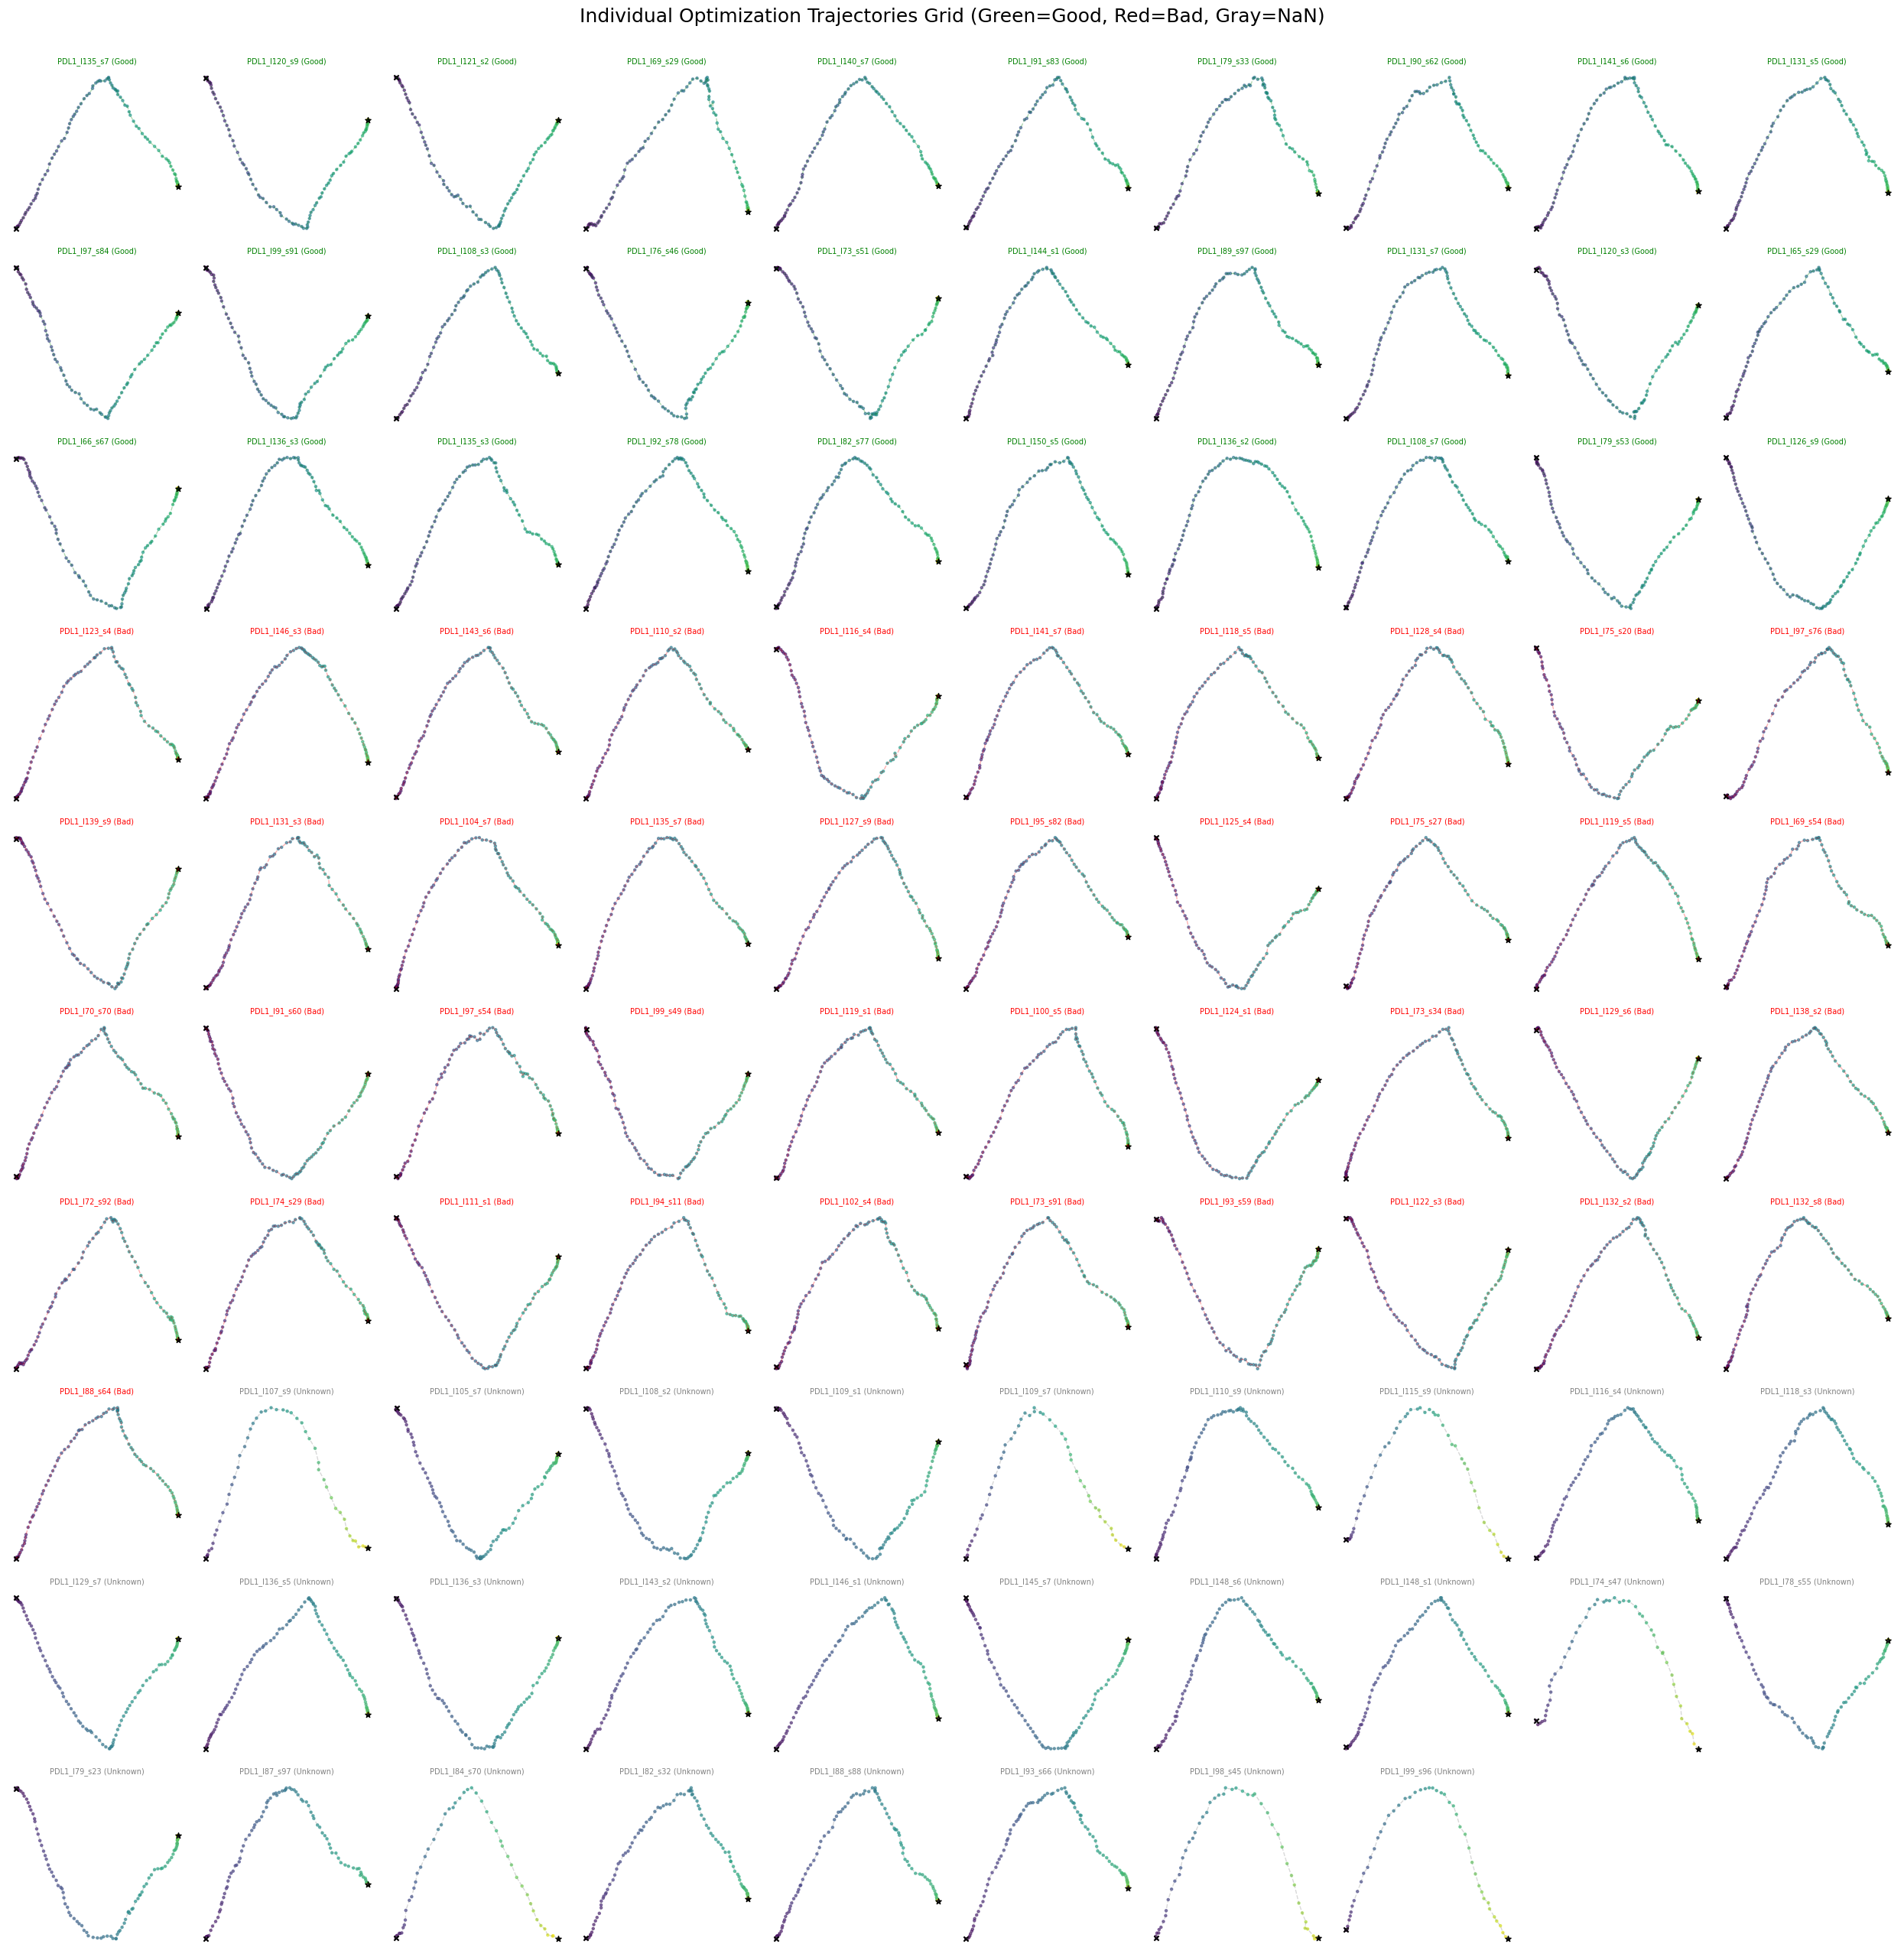

In [21]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import math
import numpy as np

def plot_all_trajectories_grid(df, max_plots=98, grid_cols=10):
    subset_df = df.head(max_plots)
    num_plots = len(subset_df)
    grid_rows = math.ceil(num_plots / grid_cols)

    # Create a massive figure
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(25, 2.5 * grid_rows))
    axes = axes.flatten()

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        ax = axes[i]
        traj_data = row['Seqmatrix']
        traj_data = traj_data[:125] if traj_data.shape[0] > 125 else traj_data

        # Status logic: Good=Green, Bad=Red, NaN=Gray
        if row['Good'] == 1.0 or row['Good'] is True:
            status = "Good"
            color = "green"
        elif row['Good'] == 0.0 or row['Good'] is False:
            status = "Bad"
            color = "red"
        else:
            status = "Unknown"
            color = "gray"

        # Reshape and Fit individual PCA
        num_iterations = traj_data.shape[0]
        X = traj_data.reshape(num_iterations, -1)
        pca = PCA(n_components=2)
        traj_2d = pca.fit_transform(X)

        # Plot trajectory path
        ax.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.3, linestyle='--', linewidth=1)
        # Use color map to show progression over time
        ax.scatter(traj_2d[:, 0], traj_2d[:, 1], c=range(num_iterations), cmap='viridis', s=5, alpha=0.6)

        # Markers for Start and End
        ax.scatter(traj_2d[0, 0], traj_2d[0, 1], c='black', marker='x', s=20)
        ax.scatter(traj_2d[-1, 0], traj_2d[-1, 1], c='black', marker='*', s=30)

        ax.set_title(f"{row['Design'][:12]} ({status})", fontsize=7, color=color)
        ax.axis('off')

    # Hide any unused axis in the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle("Individual Optimization Trajectories Grid (Green=Good, Red=Bad, Gray=NaN)", fontsize=18, y=1.02)
    plt.savefig('individual_trajectories_grid.png', dpi=1200, bbox_inches='tight')

# Run the updated grid visualization
plot_all_trajectories_grid(df, max_plots=98, grid_cols=10)

### Combined Population PCA Trajectories
This plot shows multiple design trajectories in the same PCA space. Each line represents the evolution of a design's sequence matrix, limited to the first 125 iterations.

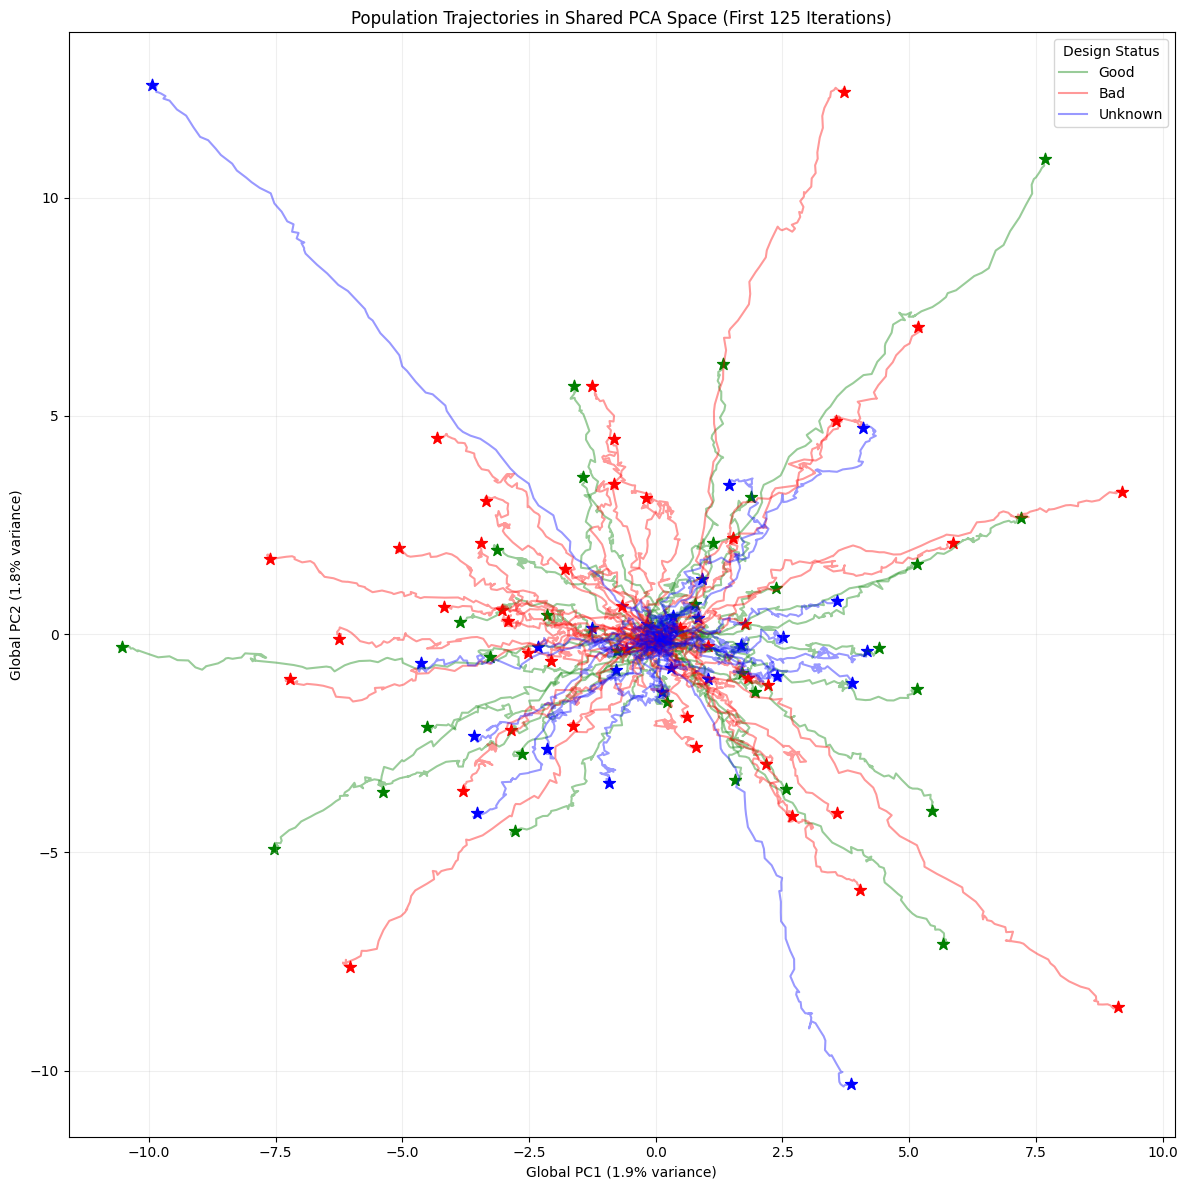

In [48]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def plot_combined_trajectories_shared_pca(df, max_designs=15, max_iters=125):
    subset_df = df.head(max_designs).copy()

    # 1. Identify max length to handle inconsistent dimensions
    max_len = max(row['Seqmatrix'].shape[1] for _, row in subset_df.iterrows())
    num_features = subset_df.iloc[0]['Seqmatrix'].shape[2]

    all_points = []
    design_trajs_padded = []

    for idx, row in subset_df.iterrows():
        traj = row['Seqmatrix'][:max_iters]
        iters, current_len, feats = traj.shape

        if current_len < max_len:
            padding = np.zeros((iters, max_len - current_len, feats))
            traj = np.concatenate([traj, padding], axis=1)

        flattened = traj.reshape(iters, -1)
        all_points.append(flattened)
        design_trajs_padded.append(flattened)

    X_global = np.vstack(all_points)
    pca = PCA(n_components=2)
    pca.fit(X_global)

    # 2. Plotting
    plt.figure(figsize=(12, 12))

    # Define color map for status
    status_colors = {"Good": "green", "Bad": "red", "Unknown": "blue"}

    # Track labels added to legend to avoid duplicates
    legend_handles = {}

    for i, (idx, row) in enumerate(subset_df.iterrows()):
        X_individual = design_trajs_padded[i]
        traj_2d = pca.transform(X_individual)

        # Map status to color
        status = "Good" if row['Good'] == 1.0 else "Bad" if row['Good'] == 0.0 else "Unknown"
        color = status_colors[status]

        # Plot path
        line, = plt.plot(traj_2d[:, 0], traj_2d[:, 1], alpha=0.4, color=color)
        if status not in legend_handles:
            legend_handles[status] = line

        # Start/End markers
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], marker='x', s=30, color=color, alpha=0.5)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], marker='*', s=80, color=color)

    plt.title(f"Population Trajectories in Shared PCA Space (First {max_iters} Iterations)")
    plt.xlabel(f"Global PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% variance)")
    plt.ylabel(f"Global PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% variance)")

    # Create a clean legend based on status
    plt.legend(legend_handles.values(), legend_handles.keys(), title="Design Status")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Visualize more designs to see the grouping effect
plot_combined_trajectories_shared_pca(df, max_designs=98, max_iters=125)

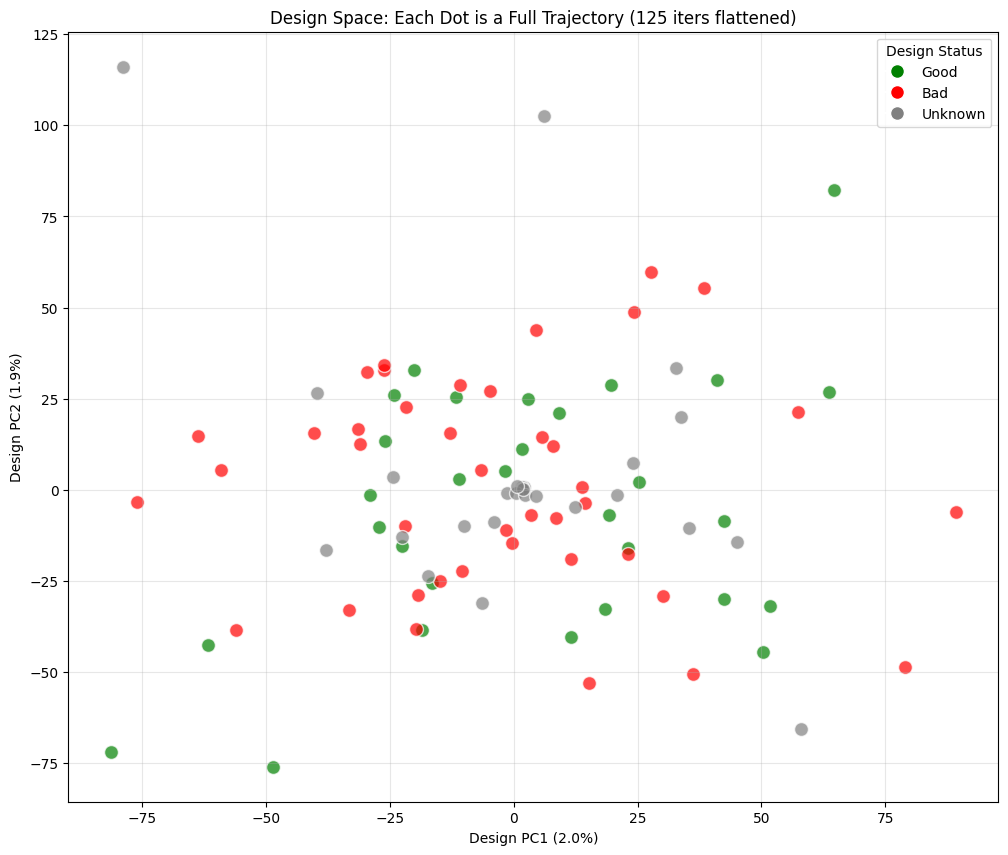

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

def plot_designs_as_dots_pca(df, max_iters=125):
    # 1. Determine global dimensions for uniform flattening
    max_len = df['Seqmatrix'].apply(lambda x: x.shape[1]).max()
    max_feats = df['Seqmatrix'].apply(lambda x: x.shape[2]).max()

    design_vectors = []
    status_info = []

    for idx, row in df.iterrows():
        # Trim/Pad iterations to a fixed window (max_iters)
        traj = row['Seqmatrix'][:max_iters]
        iters, current_len, current_feats = traj.shape

        # Pad iterations if design finished early
        if iters < max_iters:
            iter_padding = np.zeros((max_iters - iters, current_len, current_feats))
            traj = np.concatenate([traj, iter_padding], axis=0)

        # Pad Sequence Length
        if current_len < max_len:
            len_padding = np.zeros((max_iters, max_len - current_len, current_feats))
            traj = np.concatenate([traj, len_padding], axis=1)

        # Pad Features
        if current_feats < max_feats:
            feat_padding = np.zeros((max_iters, max_len, max_feats - current_feats))
            traj = np.concatenate([traj, feat_padding], axis=2)

        # Flatten entire trajectory (Iterations * Length * Features) into ONE row
        design_vectors.append(traj.flatten())

        status = "Good" if row['Good'] == 1.0 else "Bad" if row['Good'] == 0.0 else "Unknown"
        color = "green" if status == "Good" else "red" if status == "Bad" else "gray"
        status_info.append({'status': status, 'color': color, 'name': row['Design']})

    # 2. PCA on the design vectors (one row per design)
    X = np.stack(design_vectors)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    # 3. Plotting
    plt.figure(figsize=(12, 10))
    for i in range(len(X_2d)):
        plt.scatter(X_2d[i, 0], X_2d[i, 1], color=status_info[i]['color'], alpha=0.7, s=100, edgecolors='white')

    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Good', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Bad', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Unknown', markerfacecolor='gray', markersize=10)
    ]

    plt.legend(handles=legend_elements, title="Design Status")
    plt.title(f"Design Space: Each Dot is a Full Trajectory ({max_iters} iters flattened)")
    plt.xlabel(f"Design PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    plt.ylabel(f"Design PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
plot_designs_as_dots_pca(df)